# 01 - hex_proximity_plot()

This notebook __creates function hex_proximity_plot()__ based on existing hex_plot() function.

## __Import libraries__

In [1]:
from pathlib import Path

current_path = Path().resolve()

for parent in current_path.parents:
    if parent.name == "odc":
        project_root = parent
        break

print(project_root)

/home/jovyan/odc


In [2]:
import os
import sys

import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

module_path = os.path.abspath(os.path.join(project_root))
if module_path not in sys.path:
    sys.path.append(module_path)
    print("Path found")
    import odc


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/conda/envs/gds/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/envs/gds/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/conda/envs/gds/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/envs/gds/lib/python3.9/site-packages/traitlets/config/application.py", line 1053, in launch_instance
    app.start()
  File "/opt/conda/envs/g

AttributeError: _ARRAY_API not found

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

## __Config notebook__

In [ ]:
res = 8
city = 'Aguascalientes'

## __Load data__

In [ ]:
# Load data test
data_schema = 'prox_analysis'
data_table = f'proximityanalysis_v2_23_mzaageb_hex'
# Load city's hexs filtering for urban areas if required
query = f"SELECT * FROM {data_schema}.{data_table} WHERE \"city\" = '{city}\' AND \"res\" = '{res}\'"
data_gdf = odc.gdf_from_query(query, geometry_col='geometry')

# Show
print(data_gdf.crs)
print(data_gdf.shape)
data_gdf.head(2)

In [ ]:
data_gdf.columns

In [3]:
# Download area of interest (aoi)
print('--- Downloading area of interest.')
metro_schema = 'metropolis'
metro_table = 'metro_gdf_2020'
query = f"SELECT * FROM {metro_schema}.{metro_table} WHERE \"city\" LIKE \'{city}\'"
mun_gdf = odc.gdf_from_query(query, geometry_col='geometry')
mun_gdf = mun_gdf.set_crs("EPSG:4326")
aoi = mun_gdf.dissolve()

# Download Network (G, nodes, edges)
print('--- Downloading network.')
network_schema = 'osmnx'
nodes_table = 'nodes_osmnx_23_point'
edges_table = 'edges_speed_23_line'
G, nodes_gdf, edges_gdf = odc.graph_from_hippo(aoi, schema=network_schema, edges_folder=edges_table, nodes_folder=nodes_table)

# Show
print(edges_gdf.crs)
print(edges_gdf.shape)
edges_gdf.head(2)

--- Downloading area of interest.


NameError: name 'city' is not defined

## __Function development__

In [7]:
"""
This function creates a plot designed to show proximity analysis values.

Arguments:
     gdf_data (geopandas.GeoDataFrame): GeoDataFrame with the data to be plotted.
     column (str): Name of the column to plot from the gdf_data GeoDataFrame.
     gdf_edges (geopandas.GeoDataFrame): GeoDataFrame with the edges (streets) from Open Street Map. 
                                         Must contain the column 'highway', which helps categorize roads by type.
     ax (matplotlib.axes): ax to use in the plot
     plot_title (str): Name of the plot title.

Keyword Arguments:
     plot_boundary (tuple, optional): Tuple containing boolean on position [0]. 
                                     If true, a gdf can be specified on position [1] and a boundary is ploted.
                                     Defaults to (False, '')
    save_png (tuple, optional): Tupple containing boolean on position [0].
                                If true, a string can be specified on position [1] indicating the directory and file name where the png is saved.
                                Defaults to (False, '../output/figures/plot.png')
    png_transparency (bool): Saves the png with transparency or not. Defaults to False.
    png_dpi (int): Sets the resolution to be used to save the png. Defaults to 300.
    save_pdf (tuple, optional): Tupple containing boolean on position [0].
                                If true, a string can be specified on position [1] indicating the directory and file name where the pdf is saved.
                                Defaults to (False, '../output/figures/plot.pdf') 
    show_plot (bool): Shows the plot or not. Defaults to True.
"""

"\nThis function creates a plot designed to show proximity analysis values.\n\nArguments:\n     gdf_data (geopandas.GeoDataFrame): GeoDataFrame with the data to be plotted.\n     column (str): Name of the column to plot from the gdf_data GeoDataFrame.\n     gdf_edges (geopandas.GeoDataFrame): GeoDataFrame with the edges (streets) from Open Street Map. \n                                         Must contain the column 'highway', which helps categorize roads by type.\n     ax (matplotlib.axes): ax to use in the plot\n     plot_title (str): Name of the plot title.\n\nKeyword Arguments:\n     plot_boundary (tuple, optional): Tuple containing boolean on position [0]. \n                                     If true, a gdf can be specified on position [1] and a boundary is ploted.\n                                     Defaults to (False, '')\n    save_png (tuple, optional): Tupple containing boolean on position [0].\n                                If true, a string can be specified on positio

In [83]:
def plot_hex_proximity(gdf_data, column, gdf_edges, ax, plot_title,
                       plot_boundary = (False, ''),
                       save_png = (False, '../output/figures/plot.png'),
                       png_transparency = False,
                       png_dpi = False,
                       save_pdf = (False, '../output/figures/plot.pdf'),
                       show_plot = True
                      ):
    # --------------- DIVIDE THE PLOT
    if ('min' in column) or ('idx' in column):
        # Create a divider for the provided ax
        divider = odc.make_axes_locatable(ax)
        # Create an axe for the colorbar (which has cax=cax). 
        # The size will be the "size%" of the main ax, while there's a spacing (pad) between the main ax and the colorbar
        cax = divider.append_axes("bottom", size="5%", pad=0.1)
    
    # --------------- PLOT PROXIMITY DATA (Amenity availability (count), proximity index (idx) or time data)
    
    # Plot amenity availability (count) data
    # (e.g. column 'preescolar_15min', which indicates the average number of kindergardens on a 15 minutes walk by hex)
    if 'min' in column:
        title_addition = '(Amenity availability)'
        # Plot proximity data using the viridis color palette (Commonly used for proximity data)
        gdf_data.plot(ax=ax,column=column,cmap='viridis',legend=True,cax=cax,legend_kwds={'label':column,'orientation': "horizontal"},zorder=1)
    
    # Plot proximity index (idx) data
    # (e.g. column 'idx_preescolar', which indicates the proximity index (using a sigmodial function) for kindergardens)
    elif 'idx' in column:
        title_addition = '(Sigmodial index)'
        # Plot proximity data using the viridis color palette (Commonly used for proximity data)
        gdf_data.plot(ax=ax,column=column,cmap='cividis',legend=True,cax=cax,legend_kwds={'label':column,'orientation': "horizontal"},zorder=1)
    
    # Plot time data
    # (e.g. columns 'max_preescolar' or 'median_time', which indicates average time (minutes) data and is categorized in time bins)
    elif ('max' in column) or ('time' in column):
        title_addition = '(Time analysis)'
        
        # Categorize time data in time bins
        gdf_data.loc[gdf_data[column]>=60 , f'{column}_cat'] = '60 or more minutes'
        gdf_data.loc[(gdf_data[column]>=45 )&
                     (gdf_data[column]<60), f'{column}_cat'] = '45 minutes to 60 minutes'
        gdf_data.loc[(gdf_data[column]>=30)&
                     (gdf_data[column]<45), f'{column}_cat'] = '30 minutes to 45 minutes'
        gdf_data.loc[(gdf_data[column]>=15)&
                     (gdf_data[column]<30), f'{column}_cat'] = '15 minutes to 30 minutes'
        gdf_data.loc[(gdf_data[column]<15), f'{column}_cat'] = '15 minutes or less'
        
        # Order data
        categories = ['15 minutes or less','15 minutes to 30 minutes','30 minutes to 45 minutes','45 minutes to 60 minutes','60 or more minutes']
        gdf_data[f'{column}_cat'] = pd.Categorical(gdf_data[f'{column}_cat'], categories=categories, ordered=True)

        # Plot proximity data using the viridis color palette (Commonly used for proximity data)
        gdf_data.plot(ax=ax,column=f'{column}_cat',cmap='viridis_r',legend=True,legend_kwds={'fontsize':7.5,'loc':'lower left'},zorder=1)

    # --------------- PLOT OPTIONAL COMPLEMENTS (Area of interest boundary and streets)
    # Plot boundary
    if plot_boundary[0]:
        plot_boundary[1].boundary.plot(ax=ax,color='#2b2b2b',linestyle='--',linewidth=0.5,zorder=2)
    
    # Plot edges (Main)
    edges_shown_a = ['motorway','motorway_link']
    gdf_edges_main = gdf_edges[gdf_edges['highway'].isin(edges_shown_a)].copy()
    if len(gdf_edges_main) > 0:
        gdf_edges_main.plot(ax=ax,color='#000000',alpha=0.5,linewidth=5,zorder=3)
    # Plot edges (Primary and secondary)
    edges_shown_b = ['primary','primary_link','secondary','secondary_link']
    gdf_edges_primary = gdf_edges[gdf_edges['highway'].isin(edges_shown_b)].copy()
    if len(gdf_edges_primary) > 0:
        gdf_edges_primary.plot(ax=ax,color='#898989',alpha=0.5,linewidth=1.0,zorder=3)
    
	# Format plot
    ax.set_title(f"""{plot_title} 
{title_addition}""",fontdict={'fontsize':15})
    
    # Save or show plot
    if save_png[0]:
        plt.savefig(save_png[1],dpi=png_dpi,transparent=png_transparency)
    if save_pdf[0]:
        plt.savefig(save_pdf[1])
    if show_plot:
        plt.show()

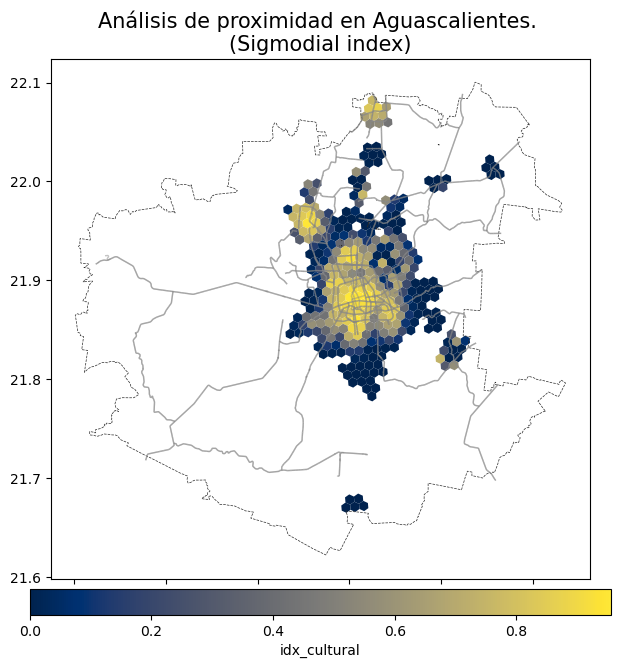

In [84]:
fig,ax = plt.subplots(figsize=(7.5,7.5))

#cultural_15min
#max_cultural
#idx_cultural

plot_hex_proximity(gdf_data = data_gdf,
                       column = 'idx_cultural',
                       gdf_edges = edges_gdf,
                       ax=ax,
                       plot_title = f'Análisis de proximidad en {city}.',
                       plot_boundary = (True, aoi),
                       save_png = (False, '../output/figures/plot.png'),
                       png_transparency = False,
                       png_dpi = False,
                       save_pdf = (False, '../output/figures/plot.pdf'),
                       show_plot = True
                      )